# ACC102 Track 2 GitHub Project
# S&P 500 Financial Data Analysis and Visualization


In [8]:
# 'import' loads an external library so we can use its functions in this notebook.
# 'wrds'   connects Python to the WRDS financial database server.
# 'pandas' (nicknamed 'pd') is the main library for working with data tables.
import wrds
import pandas as pd
import matplotlib.pyplot as plt
!pip install wrds

In [9]:
# Replace the string below with your own WRDS account name (e.g. 'jsmith').
username = "emily2468953"

# wrds.Connection() opens a live connection to the WRDS database server.
# We store the connection object in 'db' so every later query can reuse it.
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


Average daily return: 0.0005670707472178061
Annual volatility: 0.2133426413111788
Final cumulative return: 1.8204674787939346


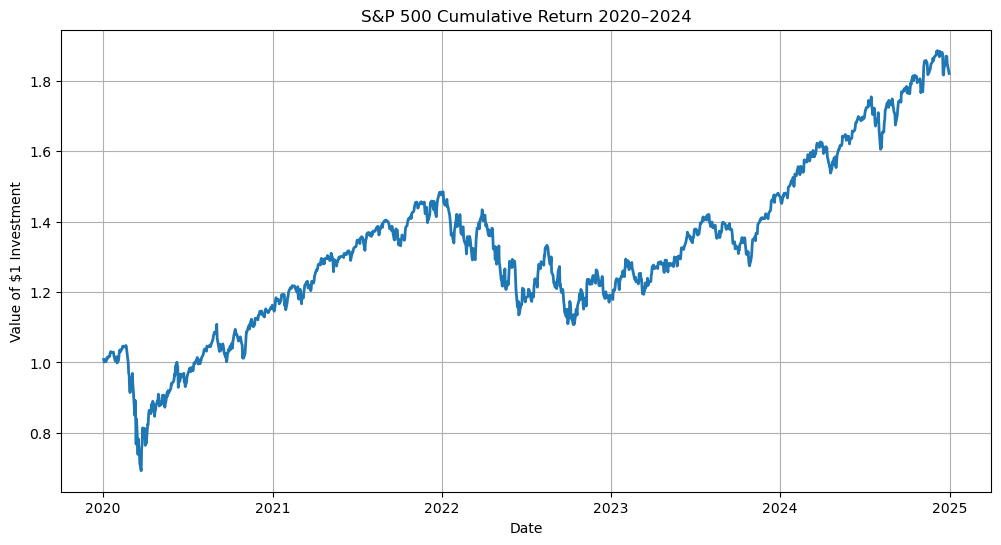

wenjianjia:  C:\Users\ASUS\Downloads


In [12]:
# --------------------------
# Step 1: Download the data of S&P 500 from WRDS 
# --------------------------
# Use lowercase column names: date, sprtrn
query = """
SELECT date, sprtrn
FROM crsp.dsi
WHERE date >= '2020-01-01'
  AND date <= '2024-12-31'
ORDER BY date
"""

# Execute data into a DataFrame
df = db.raw_sql(query)


# --------------------------
# Step 2: Data cleaning and formatting
#Convert date to proper format and remove missing returns
# --------------------------
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['sprtrn'])


# --------------------------
# Step 3: Financial Analysis 
# Calculate cumulative return
#Cumulative return shows how $1 invested grows over time
# --------------------------
df['cumulative_return'] = (1 + df['sprtrn']).cumprod()

avg_daily = df['sprtrn'].mean()
vol = df['sprtrn'].std() * (252 ** 0.5)

print("Average daily return:", avg_daily)
print("Annual volatility:", vol)
print("Final cumulative return:", df['cumulative_return'].iloc[-1])

# --------------------------
# Step 4: Data Visualization 
# Create a clear line chart for the project 
# --------------------------
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['cumulative_return'], linewidth=2)
plt.title('S&P 500 Cumulative Return 2020–2024')
plt.xlabel('Date')
plt.ylabel('Value of $1 Investment')
plt.grid(True)

#Save image for the project
plt.savefig('sp500_return.png', dpi=300)
plt.show()

# --------------------------
# Step 5: Export Results
# --------------------------
# EXport cleaned data to Excel for users
df.to_excel('sp500_analysis.xlsx', index=False)
